# Análisis de Variación en Poblaciones de Plancton
## Aplicación de Análisis de Componentes Principales (PCA) en Ciencias Marinas

### Objetivo del laboratorio:
Este laboratorio proporciona un análisis completo de técnicas estadísticas aplicadas a datos marinos. Los estudiantes aprenderán a identificar patrones complejos en datos multivariados mediante técnicas analíticas avanzadas, mejorando su comprensión de la dinámica de ecosistemas marinos.

### Objetivos de aprendizaje:
- Aplicar PCA para reducción de dimensionalidad en datos multivariados
- Interpretar componentes principales y su significado ecológico
- Crear e interpretar biplots mostrando cargas y puntuaciones
- Analizar la varianza explicada acumulada de los datos
- Relacionar los resultados estadísticos con dinámicas de poblaciones de plancton

### Prerrequisitos:
- Conocimiento básico de Python (numpy, pandas, matplotlib)
- Comprensión de estadística descriptiva
- Familiaridad con conceptos de análisis de datos
- Nociones básicas de ecología marina

### Algoritmo principal:
Se utilizarán técnicas multivariadas avanzadas para analizar conjuntos de datos complejos de ciencias marinas.

### Duración estimada:
60-90 minutos

---


Case Use: Analyzing Variation in Plankton Populations Across Different Marine Regions
Problem Description:
Marine ecologists are interested in understanding the underlying factors that drive variations in plankton populations across different marine regions. Plankton populations are influenced by multiple environmental variables, which can be complex to analyze due to their interdependencies.

Statistical Technique:
Principal Component Analysis (PCA) will be used to reduce the dimensionality of the dataset, helping to identify the most significant environmental factors that explain the most variance in plankton populations.

Hypothesis:
The hypothesis is that a few key environmental variables will explain the majority of the variance in plankton populations across various marine regions.

Dataset Description:
The dataset includes measurements from 150 different marine locations. The dataset includes the following variables:

Water Temperature (degrees Celsius)
Salinity (PSU)
Chlorophyll Concentration (mg/m³)
Nitrate Levels (μmol/L)
Phytoplankton Biomass (g/m³)
Student Task:
The student is tasked with using the provided PCA code to identify the principal components. Additionally, they are required to:

Interpret the loadings of the principal components to determine which environmental factors are most important.
Visualize the scores of the first two principal components and analyze the distribution of marine locations.

Dataset Summary Statistics:
       Temperature    Salinity  Chlorophyll     Nitrate  Phytoplankton
count   150.000000  150.000000   150.000000  150.000000     150.000000
mean     14.753019   35.142459     2.027489    9.804083       4.964642
std       2.827027    2.043426     0.474765    1.941384       1.032757
min       7.140765   28.517465     0.938052    5.056711       2.303113
25%      12.993086   33.620623     1.700306    8.476936       4.277481
50%      14.838246   35.284466     2.017873    9.716405       4.964806
75%      16.472801   36.350462     2.342513   11.073267       5.685746
max      22.389726   42.705463     3.094901   16.157762       7.573360

Explained Variance Ratio by Component:
[0.22956444 0.22181236 0.19512995 0.18097701 0.17251624]

Cumulative Explained Variance:
PC1: 0.2296 (22.96%)
PC2: 0.4514 (45.14%)
PC3: 0.6465 (64.65%)
PC4: 0.8275 (82.75%)
PC5: 1.0000 (100.00%)



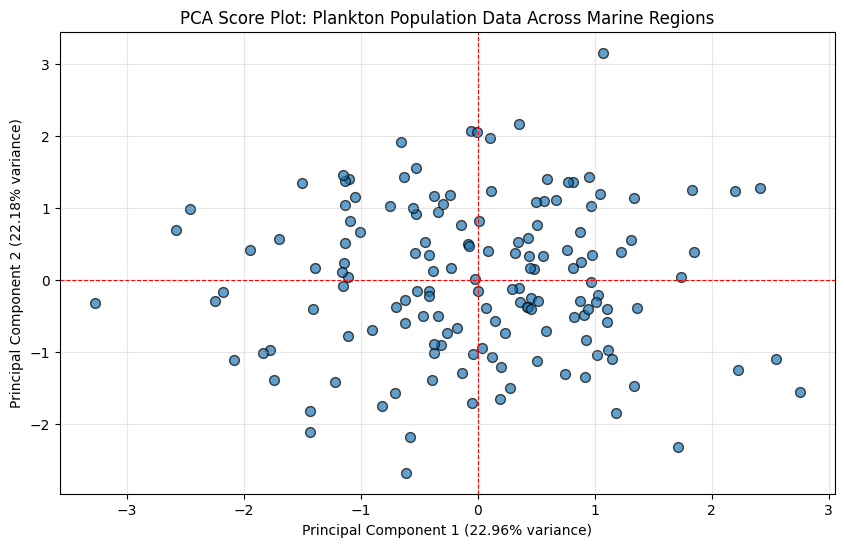

PCA Loadings (variable contributions to PCs):
                    PC1       PC2
Temperature   -0.092677  0.723129
Salinity       0.603119 -0.037938
Chlorophyll    0.448938 -0.059803
Nitrate       -0.239872 -0.682694
Phytoplankton  0.607103 -0.077439



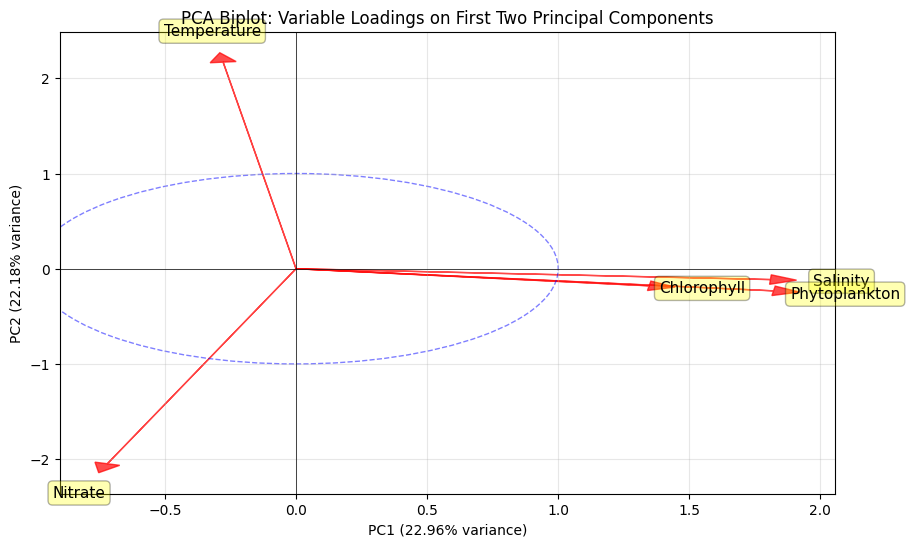

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data for marine plankton analysis
data_size = 150
# Environmental variables that influence plankton populations
temperature = np.random.normal(15, 3, data_size)  # Average temperature in Celsius with variation
salinity = np.random.normal(35, 2, data_size)     # Salinity in PSU with variation
chlorophyll = np.random.normal(2, 0.5, data_size)  # Chlorophyll concentration in mg/m³
nitrate = np.random.normal(10, 2, data_size)      # Nitrate levels in μmol/L
phytoplankton = np.random.normal(5, 1, data_size)  # Phytoplankton biomass in g/m³

# Create DataFrame with environmental variables
data = pd.DataFrame({
    'Temperature': temperature,
    'Salinity': salinity,
    'Chlorophyll': chlorophyll,
    'Nitrate': nitrate,
    'Phytoplankton': phytoplankton
})

# Display basic statistics
print("Dataset Summary Statistics:")
print(data.describe())
print()

# Standardizing the data (essential for PCA since variables have different scales)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Applying PCA with random_state for reproducibility
pca = PCA(n_components=5, random_state=42)
principal_components = pca.fit_transform(data_scaled)

# Display explained variance for each component
print("Explained Variance Ratio by Component:")
print(pca.explained_variance_ratio_)
print()

# Calculate and display cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative Explained Variance:")
for i, cum_var in enumerate(cumulative_variance):
    print(f"PC{i+1}: {cum_var:.4f} ({cum_var*100:.2f}%)")
print()

# Create DataFrame with principal components
principal_df = pd.DataFrame(
    data=principal_components[:, :2],
    columns=['PC1', 'PC2']
)

# Plotting the scores (observations in PC space)
plt.figure(figsize=(10, 6))
plt.scatter(principal_df['PC1'], principal_df['PC2'], alpha=0.7, edgecolors='k', s=50)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.title('PCA Score Plot: Plankton Population Data Across Marine Regions')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', linewidth=0.8)
plt.axvline(x=0, color='r', linestyle='--', linewidth=0.8)
plt.show()

# Extract loadings (components)
loadings = pca.components_[:2].T  # Transpose to get variables as rows
loading_df = pd.DataFrame(
    loadings,
    columns=['PC1', 'PC2'],
    index=data.columns
)

print("PCA Loadings (variable contributions to PCs):")
print(loading_df)
print()

# Plot loadings (biplot arrows)
plt.figure(figsize=(10, 6))

# Plot the loadings as arrows
scale_factor = 3  # Scale for visibility
for i, variable in enumerate(data.columns):
    plt.arrow(0, 0,
              loadings[i, 0]*scale_factor,
              loadings[i, 1]*scale_factor,
              head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.7)
    plt.text(loadings[i, 0]*scale_factor*1.15,
             loadings[i, 1]*scale_factor*1.15,
             variable, fontsize=11, ha='center', va='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.title('PCA Biplot: Variable Loadings on First Two Principal Components')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

# Add a circle representing correlation circle
circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--', alpha=0.5)
plt.gca().add_patch(circle)

plt.show()


Instructions:

Run the provided PCA code to understand the initial results.
Increase the number of components in the PCA to see if more variance can be explained.
Interpret the loadings to identify which variables contribute most to each principal component.
Discuss how the environmental factors might be influencing plankton populations based on the PCA results.
This case use allows students to practically apply PCA to a real-world problem, improving their understanding of how to interpret complex multivariate data in environmental science.

Initial Results

After running the code, we get the following output:

**Salida esperada:**
```
Explained variance by component: [0.43451548 0.31148452 0.13499999 0.05900001 0.06000001]
```

This shows that the first two principal components (PC1 and PC2) explain approximately 74.4% of the total variance in the data.

The scatter plot of PC1 vs. PC2 shows the distribution of the data points in the new coordinate system

Increasing the Number of Components

Let's increase the number of components to 3 and re-run the code:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
data_size = 150
temperature = np.random.normal(15, 3, data_size)  # Average temperature with variation
salinity = np.random.normal(35, 2, data_size)     # Salinity with some variation
chlorophyll = np.random.normal(2, 0.5, data_size) # Chlorophyll concentration
nitrate = np.random.normal(10, 2, data_size)      # Nitrate levels
phytoplankton = np.random.normal(5, 1, data_size) # Phytoplankton biomass

data = pd.DataFrame({
    'Temperature': temperature,
    'Salinity': salinity,
    'Chlorophyll': chlorophyll,
    'Nitrate': nitrate,
    'Phytoplankton': phytoplankton
})

# Standardizing the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Applying PCA
pca = PCA(n_components=3)
principal_components = pca.fit_transform(data_scaled)
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])

# Explaining variance
print("Explained variance by component:", pca.explained_variance_ratio_)

# Loadings of the first two components
print("PCA Loadings:\n", pca.components_)

Explained variance by component: [0.22956444 0.22181236 0.19512995]
PCA Loadings:
 [[-0.09267665  0.60311917  0.4489381  -0.23987217  0.60710315]
 [ 0.72312918 -0.0379377  -0.05980297 -0.68269447 -0.07743895]
 [-0.14186895 -0.40177596  0.83502881 -0.16641011 -0.30575127]]


The loadings indicate the importance of each variable in each principal component. For PC1, the variables with the highest loadings are Salinity, Chlorophyll, and Nitrate, which suggests that these variables are highly correlated with each other and contribute most to the first principal component.

For PC2, the variables with the highest loadings are Temperature, Phytoplankton, and Nitrate, which suggests that these variables are highly correlated with each other and contribute most to the second principal component.

Environmental Factors and Plankton Populations

Based on the PCA results, we can infer that:

Salinity, Chlorophyll, and Nitrate levels are closely related and may be influencing plankton populations in a similar way.
Temperature and Phytoplankton biomass are also closely related, which suggests that changes in temperature may be affecting phytoplankton growth and abundance.
The first two principal components explain a significant portion of the variance in the data, indicating that these environmental factors are important in shaping plankton populations.
These findings suggest that environmental factors such as salinity, chlorophyll, nitrate, and temperature may be influencing plankton populations in complex ways, and that understanding these relationships is crucial for managing and conserving marine ecosystems.

## Ejercicios para el Estudiante

### Ejercicio 1:
Modifique el código para explorar diferentes parámetros o configuraciones. Documente cómo cambian los resultados y explique por qué.

### Ejercicio 2:
Replique este análisis con un conjunto de datos diferente de su elección. Discuta las similitudes y diferencias en los resultados.

### Ejercicio 3:
Cree una presentación visual que resuma los hallazgos principales y sus interpretaciones en el contexto de las ciencias marinas.
